In [1]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

DATA_DIR = '/content/drive/MyDrive/TimeSeriesDeepLearning_FIM601/kaggle_data/optiver-realized-volatility-prediction'
rng = np.random.default_rng()

Mounted at /content/drive


# Data Breakdown

### Book Data
* `time_id`: The dataset is composed of 10 minute blocks. Each 10 minute block is uniquely identified by its `time_id`. 
* `seconds_in_bucket`: The amount of seconds that has elapsed since the beginning of the bucket identified by `time_id`. This is a snapshot of the market at this particular time. If a particular second is missing, it is assumed that the market is unchanged from the last entry. 
* `[bid/ask]_price[1/2]`: Exactly what it sounds like. `bid_price2` < `bid_price1` < `ask_price1` < `ask_price2`. 
* `stock_id`: Unique stock identifier. 

### Trade Data
* `time_id`: The same as in Book Data
* `seconds_in_bucket`: Similar to `seconds_in_bucket` from Book Data. This is the second for which the trade data is considered. I.e. all other data summarizes all the trade information over the time period `[seconds_in_bucket, seconds_in_bucket + 1)`. If a particular second is missing, it is not assumed that the market is unchanged from the last entry. Each entry signifies market activity. If there is no entry for a particular second, no trades were executed over that second.  
* `price`: This is the volume weighted price over the second. 
* `size`: This is the number of shares traded. 
* `order_count`: This is the number of unique trade orders placed in that second. 

# Encoding

This encoding is inspired by [this paper](https://arxiv.org/pdf/2304.02472). It differs, since we are not (yet) interested in applying a pre-trained image model, which is what they are trying to do in the end. 

In this encoding, our x axis is time, and y axis is price. We discretize the price axis, and aggregate the data correspondingly. Our channels are as follow:
* `bid_size1`
* `bid_size2`
* `ask_size1`
* `ask_size2`
* `size` 
* `order_count`

We will have to have a different encoding scheme to add more features. 
The shape of one sample is [600, 600, 6]. 

Alternative probably better idea: Represent group bid sizes and ask sizes onto two channels. New channel architecture:
* `bid_sizes`
* `ask_sizes`
* `size`
* `order_count`

Idea from paper: Pad size to accentuate impact of trades. If padded sizes overlap, just sum them

# BAD ASSUMPTION THAT WE WILL USE: (`stock_id`, `time_id`) samples are i.i.d. 
We can think about fixing it later

Potential fix, add a token for the stock_id, so that the model can learn different volatility profiles for different stock ids

In [2]:
class OrderFlowDataset(Dataset):
    def __init__(self, target_csv_path, book_path, trade_path, transform=None):
        self.target = pd.read_csv(target_csv_path)
        self.index_map = self.target[['stock_id', 'time_id']].to_numpy()
        self.target = self.target.to_numpy()

        self.book_path = book_path
        self.trade_path = trade_path
        self.transform = transform

    def __len__(self):
        return len(self.index_map)
    
    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        stock_id, time_id = self.index_map[idx]
        book_data = pd.read_parquet(f"{self.book_path}/stock_id={stock_id}", filters=[('time_id', '==', time_id)])
        trade_data = pd.read_parquet(f"{self.trade_path}/stock_id={stock_id}", filters=[('time_id', '==', time_id)])
        target = self.target[idx, 2]

        sample = {"book": book_data, "trade": trade_data, "r_vol": target}

        if self.transform:
            sample = self.transform(sample)
        
        return sample

Here is an example of how to use the dataset:

In [3]:
of_datset = OrderFlowDataset(f"{DATA_DIR}/train.csv", f"{DATA_DIR}/book_train.parquet", f"{DATA_DIR}/trade_train.parquet")
sample = of_datset[0]
print(f"Book Sample: \n{sample["book"]}\nTrade Sample: \n {sample["trade"]}\nRealized Volatility Sample Target: \n{sample["r_vol"]}")

Book Sample: 
     time_id  seconds_in_bucket  bid_price1  ask_price1  bid_price2  \
0          5                  0    1.001422    1.002301    1.001370   
1          5                  1    1.001422    1.002301    1.001370   
2          5                  5    1.001422    1.002301    1.001370   
3          5                  6    1.001422    1.002301    1.001370   
4          5                  7    1.001422    1.002301    1.001370   
..       ...                ...         ...         ...         ...   
297        5                585    1.003129    1.003749    1.003025   
298        5                586    1.003129    1.003749    1.002612   
299        5                587    1.003129    1.003749    1.003025   
300        5                588    1.003129    1.003749    1.002612   
301        5                593    1.003129    1.003749    1.003025   

     ask_price2  bid_size1  ask_size1  bid_size2  ask_size2  
0      1.002353          3        226          2        100  
1      1.

# IMPORTANT DECISION I DONT KNOW IF IS RIGHT: 
- When encoding the image, we discreteize the price level. I do not know how I should choose the min and max price values. If it is over all prices in the entire data set, there is basically no movement at all. However if the encoding is for each sample, then we lose information about what the prices are, which is important for volatility. Not sure how to strike a happy medium 
- Additionally, choosing the mesh of the price discretization is important, and is an important hyperparameter I'm unsure how to choose. I think we choose it so that we can use the image as an input for a pre-trained model. 

In [4]:
class ToImage(object):
    def __init__(self, output_size=(600, 600, 4), bounds="auto"):
        self.output_size = output_size
        self.bounds = bounds

    def __call__(self, sample):
        book, trade, r_vol = sample["book"], sample["trade"], sample["r_vol"]
        n_time, n_price, n_channels = self.output_size
        image = np.zeros((n_time, n_price, n_channels), dtype=np.int32)

        # Compute per-sample bounds when set to auto.
        if self.bounds == "auto":
            min_price = min(book["bid_price1"].min(), book["bid_price2"].min(),
                            book["ask_price1"].min(), book["ask_price2"].min())
            max_price = max(book["bid_price1"].max(), book["bid_price2"].max(),
                            book["ask_price1"].max(), book["ask_price2"].max())

            if not trade.empty:
                min_price = min(min_price, trade["price"].min())
                max_price = max(max_price, trade["price"].max())

            padding = 0.001 * (max_price - min_price + 1e-8)
            bounds = (min_price - padding, max_price + padding)
        else:
            bounds = self.bounds

        price_edges = np.linspace(bounds[0], bounds[1], n_price + 1)

        # Channels 0 and 1 (book): place size at exact observed second and price bin.
        bid_bin_1 = np.searchsorted(price_edges, book["bid_price1"].to_numpy()) - 1
        bid_bin_2 = np.searchsorted(price_edges, book["bid_price2"].to_numpy()) - 1
        ask_bin_1 = np.searchsorted(price_edges, book["ask_price1"].to_numpy()) - 1
        ask_bin_2 = np.searchsorted(price_edges, book["ask_price2"].to_numpy()) - 1

        sec = book["seconds_in_bucket"].to_numpy(dtype=np.int32)

        bs1 = book["bid_size1"].to_numpy(dtype=np.int32)
        bs2 = book["bid_size2"].to_numpy(dtype=np.int32)
        as1 = book["ask_size1"].to_numpy(dtype=np.int32)
        as2 = book["ask_size2"].to_numpy(dtype=np.int32)

        np.add.at(image, (sec, bid_bin_1, 0), bs1)
        np.add.at(image, (sec, bid_bin_2, 0), bs2)
        np.add.at(image, (sec, ask_bin_1, 1), as1)
        np.add.at(image, (sec, ask_bin_2, 1), as2)

        # Channels 2 and 3 (trade): place size at exact observed second and price bin.
        if not trade.empty:
            trade_sec = trade["seconds_in_bucket"].to_numpy(dtype=np.int32)
            trade_bin = np.searchsorted(price_edges, trade["price"].to_numpy(), side="right") - 1
            trade_size = trade["size"].to_numpy(dtype=np.int32)
            trade_oc = trade["order_count"].to_numpy(dtype=np.int32)
            np.add.at(image[:, :, 2], (trade_sec, trade_bin), trade_size)
            np.add.at(image[:, :, 3], (trade_sec, trade_bin), trade_oc)
        

        return {"image": image, "r_vol": r_vol}

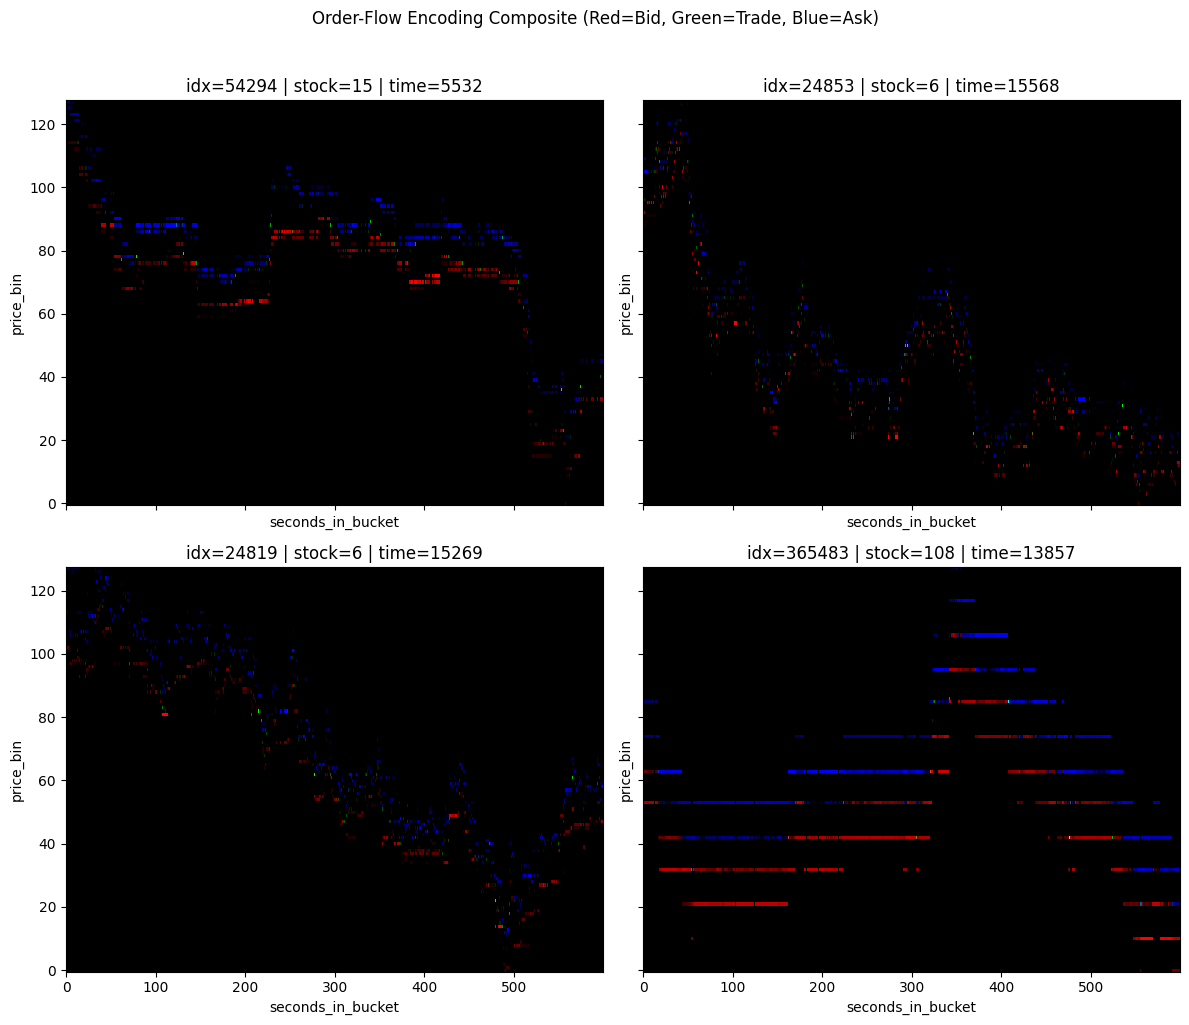

plotted_indices=[54294, 24853, 24819, 365483]


In [68]:
def robust_norm(x):
    # Normalize from nonzero intensities so sparse images don't collapse to black.
    nz = x[x > 0]
    if nz.size == 0:
        return np.zeros_like(x, dtype=np.float32)
    scale = np.percentile(nz, 99)
    if scale <= 0:
        scale = np.max(nz)
    return np.clip(x / (scale + 1e-8), 0.0, 1.0).astype(np.float32)

n_samples = 4
dataset_size = len(of_datset)

sample_indices = rng.choice(dataset_size, size=n_samples)
output_size = (600, 128, 4)
transform = ToImage(output_size = output_size)
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)

for ax, idx in zip(axes.ravel(), sample_indices):
    sample_i = of_datset[idx]
    trsfm_sample = transform(sample_i)["image"]

    bid = trsfm_sample[:, :, 0]
    ask = trsfm_sample[:, :, 1]
    trade = trsfm_sample[:, :, 2]

    bid_n = robust_norm(bid)
    ask_n = robust_norm(ask)
    trade_n = robust_norm(trade)
    rgb = np.stack([bid_n, trade_n, ask_n], axis=-1)

    stock_id, time_id = of_datset.index_map[idx]

    ax.imshow(np.transpose(rgb, (1, 0, 2)), origin="lower", aspect="auto", interpolation="nearest")
    ax.set_title(f"idx={int(idx)} | stock={int(stock_id)} | time={int(time_id)}")
    ax.set_xlabel("seconds_in_bucket")
    ax.set_ylabel("price_bin")

plt.suptitle("Order-Flow Encoding Composite (Red=Bid, Green=Trade, Blue=Ask)", y=1.02)
plt.tight_layout()
plt.show()

print(f"plotted_indices={sample_indices.tolist()}")

# Need to Implement: 
* Dataloader, and also understand the test train split formulation in pytorch 
* (Later) Rest of Feature engineering, likely added as part of the transform function pipeline
* Figure out how to add feature engineering to vit model
* add price ranges and relative price information to feature engineering 